<a href="https://colab.research.google.com/github/rb3890-rgb/clmt5405-assignments/blob/main/assignment6_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 6: Xarray with Sea Surface Temperature (SST) data

**At-home assignment — worth 10 points.** When you're done, push your work to your week folder and post a link to your completed **notebook** on the matching Courseworks assignment.

In this lab you'll apply xarray to NOAA's Extended Reconstructed SST (ERSST v5) dataset, accessed over OPeNDAP:
> https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.ersst.v5/sst.mnmean.nc

In [1]:
# === SETUP: run this cell FIRST ===
# Colab does not ship netCDF4 / zarr / pooch by default, so the data-loading
# cells below fail without these. (Safe to re-run; pip skips what's present.)
!pip install -q netCDF4 pydap zarr pooch aiohttp cftime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.8/115.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.3 MB/s eta 0:00:00


:::{admonition} Learning goals
:class: tip
This assignment exercises the xarray skills from this section:

- Open a gridded dataset over OPeNDAP and inspect its metadata (`attrs`, `long_name`)
- Compute time-means and spatial means; plot maps and timeseries
- Build a latitude ($\cos\lambda$) weighting and take an area-weighted spatial mean
- Select point locations with `.sel` and combine them along a new `location` dimension with `concat`
- Use `groupby` to build a climatology and anomalies, and `rolling` for a running mean
- Compute the Niño 3.4 ENSO index from SST anomalies
:::

:::{admonition} Working through this notebook
:class: tip
**Download** this notebook using the ⬇ button in the top-right (or copy-paste the cells into a fresh notebook), open it in your environment (JupyterLab on LEAP or Colab), and fill in your solution under each numbered task.

When you're done, follow the [submission instructions](#submission-instructions) at the bottom of the page.
:::

Start by importing NumPy, Matplotlib, and Xarray. Set the default figure size to (12, 6).

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)

## 1) Opening data and examining the metadata

### 1.1) Open the dataset and display its contents

:::{admonition} Heads up — open this dataset with `chunks`
:class: warning
This OPeNDAP server quietly returns **all zeros** (you'll get blank maps and flat
timeseries) if you request the whole array in a single shot — which several tasks below
do (the time-mean in 2.1, the spatial mean in 2.3, the ENSO index in part 4). Avoid it by
opening the data in pieces with Dask, so xarray fetches it chunk-by-chunk:

```python
ds = xr.open_dataset(url, chunks={'time': 120})
```

Everything else works exactly as usual — reductions like `.mean()` pull the data in as
needed. (You can combine this with other keywords, e.g. `drop_variables=['time_bnds']`.)
:::

In [3]:
url = 'https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.ersst.v5/sst.mnmean.nc#fillmismatch'

# Open in time-chunks so xarray fetches the array piece-by-piece over OPeNDAP.
# (Requesting the whole thing in one shot makes this THREDDS server quietly
#  return all zeros -> blank maps and flat timeseries.)
ds = xr.open_dataset(url, chunks={'time': 120})
ds

<xarray.Dataset> Size: 133MB
Dimensions:    (time: 2069, nbnds: 2, lat: 89, lon: 180)
Coordinates:
  * time       (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-05-01
  * lat        (lat) float32 356B 88.0 86.0 84.0 82.0 ... -84.0 -86.0 -88.0
  * lon        (lon) float32 720B 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 33kB dask.array<chunksize=(120, 2), meta=np.ndarray>
    sst        (time, lat, lon) float32 133MB dask.array<chunksize=(120, 89, 180), meta=np.ndarray>
Attributes: (12/39)
    climatology:                     Climatology is based on 1971-2000 SST, X...
    description:                     In situ data: ICOADS2.5 before 2007 and ...
    keywords_vocabulary:             NASA Global Change Master Directory (GCM...
    keywords:                        Earth Science > Oceans > Ocean Temperatu...
    instrument:                      Conventional thermometers
    source_comment:                  SSTs were observed by conventional therm...
    ...                              ...
    comment:                         SSTs were observed by conventional therm...
    summary:                         ERSST.v5 is developed based on v4 after ...
    dataset_title:                   NOAA Extended Reconstructed SST V5
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    data_modified:                   2026-06-03
    DODS_EXTRA.Unlimited_Dimension:  time

### 1.2) Print out the `long_name` attribute of each variable and coordinate

In [4]:
# long_name for every data variable and coordinate
for name, var in ds.variables.items():
    print(f"{name:12s}: {var.attrs.get('long_name', '(no long_name)')}")

time_bnds   : Time Boundaries
sst         : Monthly Means of Sea Surface Temperature
lat         : Latitude
lon         : Longitude
time        : Time


## 2) Basic reductions, arithmetic, means, and plotting

### 2.1) Calculate the time-mean of the entire dataset
### 2.2) Plot a map of the time-mean that was generated in the above part

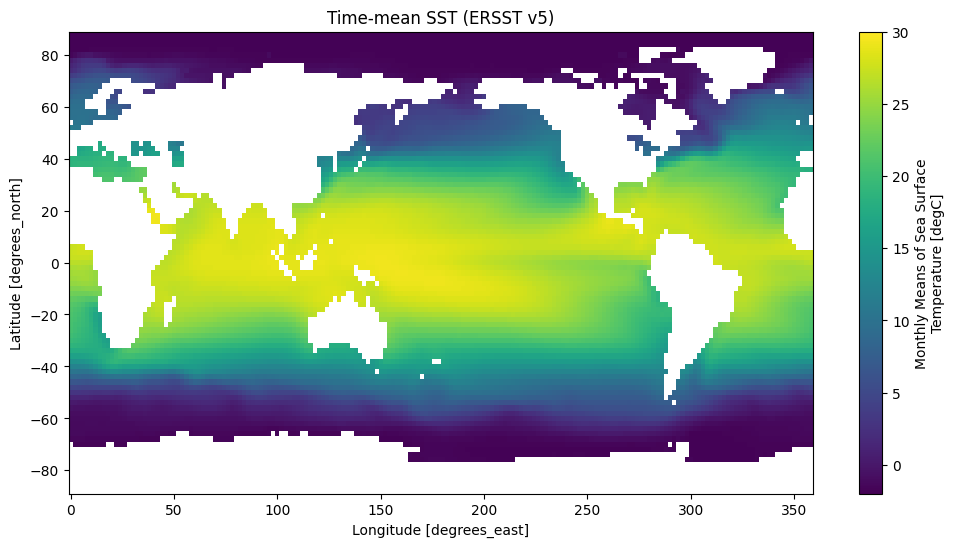

In [5]:
# 2.1) time-mean of the whole dataset
sst_timemean = ds.sst.mean(dim='time')

# 2.2) map of the time-mean
sst_timemean.plot(vmin=-2, vmax=30, cmap='viridis')
plt.title('Time-mean SST (ERSST v5)');

### 2.3) Calculate a spatial mean for each time, and plot this as a timeseries


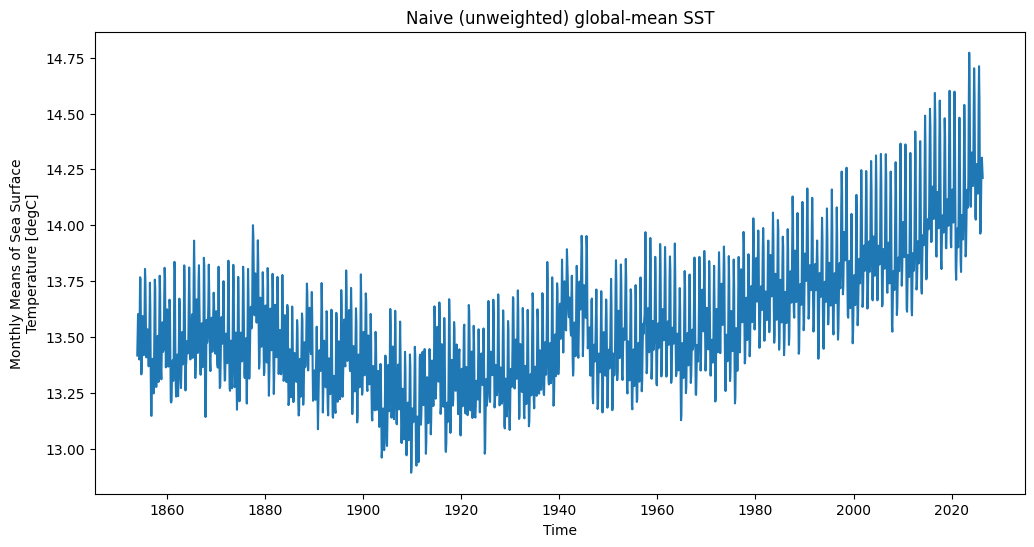

In [6]:
# Naive (unweighted) spatial mean at each time step
sst_spatial_mean = ds.sst.mean(dim=['lat', 'lon'])

sst_spatial_mean.plot()
plt.title('Naive (unweighted) global-mean SST');

### 2.4) Create a `weight` array proportional to $\cos(\lambda)$

Think carefully a about radians vs. degrees

The goal here is to realize that the dataset is provided on a $2^o$X$2^o$ lat-lon grid. But we know that the distance between longitude lines shrinks as we approach the poles.

This means that if we take a naive mean (as done in the above part), we are overemphasizing the influence of the regions away from the equator (since their area is smaller but they contribute the same to the mean). So here we plan to appropriately weight our data.



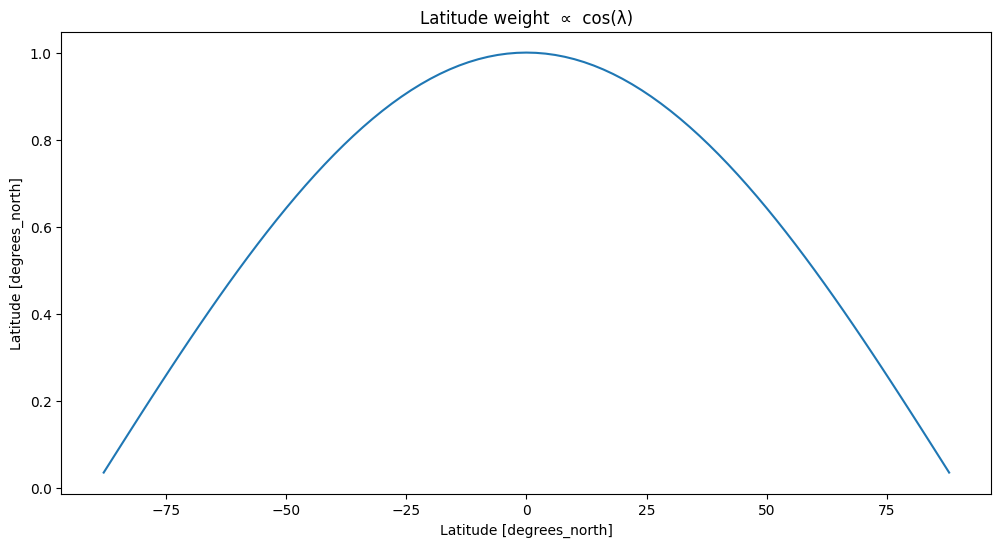

In [7]:
# Grid boxes shrink toward the poles, so the naive mean over-weights high
# latitudes. Weight each latitude by cos(latitude). Latitude is in DEGREES,
# so convert to radians before taking the cosine.
weight = np.cos(np.deg2rad(ds.lat))
weight.name = 'weight'

weight.plot()
plt.title('Latitude weight  ∝  cos(λ)');

### 2.5) Redo the calculation of the spatial mean for each time, and plot this as a timeseries


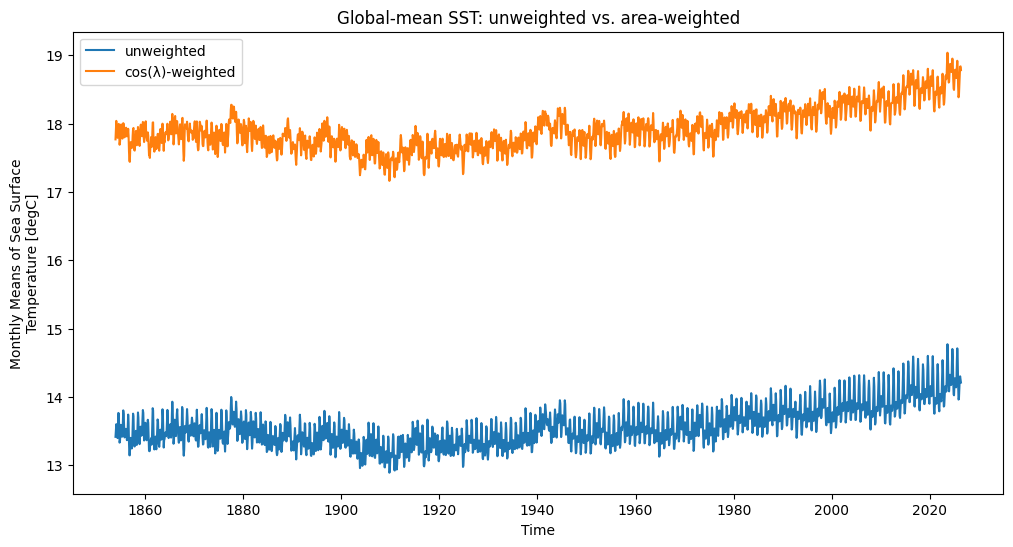

In [8]:
# Area-weighted spatial mean.  .weighted() handles the land NaNs correctly.
sst_weighted_mean = ds.sst.weighted(weight).mean(dim=['lat', 'lon'])

sst_spatial_mean.plot(label='unweighted')
sst_weighted_mean.plot(label='cos(λ)-weighted')
plt.legend()
plt.title('Global-mean SST: unweighted vs. area-weighted');

##  3) Selecting and Merging Data

For the next problem, use the following approximate locations of four different locations in the ocean.

| city | lon | lat |
| -- | -- | -- |
| Equatorial Pacific (EP) | 250 E | 0 N |
| Southern Ocean (SO) | 50 E | 60 S |
| North Atlantic (NAtl) | 300 E | 30 N |
| Arabian Sea (AS) | 60 E | 20 N |

### 3.1) Create a dataset for each point from the global dataset

In [9]:
# Approximate ocean locations (lon in degrees East, lat in degrees North)
ep   = ds.sst.sel(lon=250, lat=0,   method='nearest')   # Equatorial Pacific
so   = ds.sst.sel(lon=50,  lat=-60, method='nearest')   # Southern Ocean
natl = ds.sst.sel(lon=300, lat=30,  method='nearest')   # North Atlantic
arab = ds.sst.sel(lon=60,  lat=20,  method='nearest')   # Arabian Sea
ep

<xarray.DataArray 'sst' (time: 2069)> Size: 8kB
dask.array<getitem, shape=(2069,), dtype=float32, chunksize=(120,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-05-01
    lat      float32 4B 0.0
    lon      float32 4B 250.0
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]
    _ChunkSizes:   [  1  89 180]

### 3.2) Combine these four datasets into a new dataset with the new dimension `location`

Create a new dimension coordinate to hold the location name.
Display the combined dataset.

In [10]:
# Combine the four points along a new 'location' dimension
sst_locations = xr.concat([ep, so, natl, arab], dim='location')
sst_locations['location'] = ['EP', 'SO', 'NAtl', 'AS']
sst_locations

<xarray.DataArray 'sst' (location: 4, time: 2069)> Size: 33kB
dask.array<concatenate, shape=(4, 2069), dtype=float32, chunksize=(1, 120), chunktype=numpy.ndarray>
Coordinates:
  * location  (location) <U4 64B 'EP' 'SO' 'NAtl' 'AS'
  * time      (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-05-01
    lat       (location) float32 16B 0.0 -60.0 30.0 20.0
    lon       (location) float32 16B 250.0 50.0 300.0 60.0
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]
    _ChunkSizes:   [  1  89 180]

### 3.3) Plot the SST at each location as a timeseries over the last 3 years


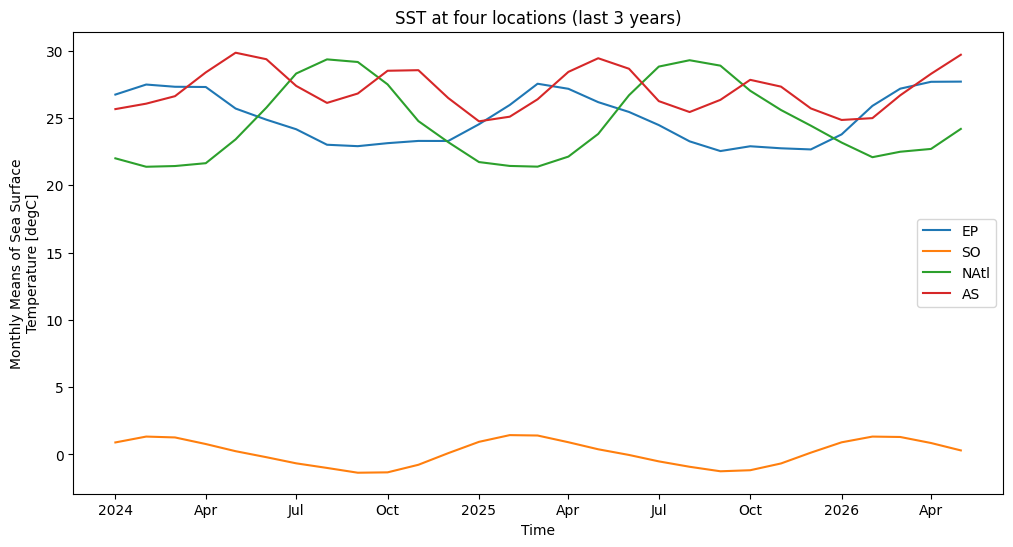

In [11]:
# Last 3 years of the record
last_year = int(str(ds.time[-1].values)[:4])
recent = sst_locations.sel(time=slice(f'{last_year - 2}', None))

for loc in recent.location.values:
    recent.sel(location=loc).plot(label=str(loc))
plt.legend()
plt.title('SST at four locations (last 3 years)');

## 4) Group by and ENSO: Reproduce the SST curve from the figure below


![enso](https://www.ncdc.noaa.gov/monitoring-content/teleconnections/eln-f-pg.gif)


You don't have to match the stylistic details, or use different colors above and below zero, just the "3mth running mean" curve.

Here will will calculate the NINO 3.4 index of El Nino variabillity (which is the quantity shown in the above plot) and use it to analyze datasets.


- The Niño 3.4 region is defined as the region between +/- 5 deg. lat, 170 W - 120 W lon.
- Warm or cold phases of the Oceanic Niño Index are defined by a five consecutive 3-month running mean of sea surface temperature (SST) anomalies in the Niño 3.4 region that is above the threshold of +0.5°C (warm), or below the threshold of -0.5°C (cold). This is known as the Oceanic Niño Index (ONI).

(Note that "anomaly" means that the seasonal cycle, also called the "climatology" has been removed.)


Also for this part: Drop the `time_bnds` variable as we did in class and trim the data to 1950 onward for this assignment.

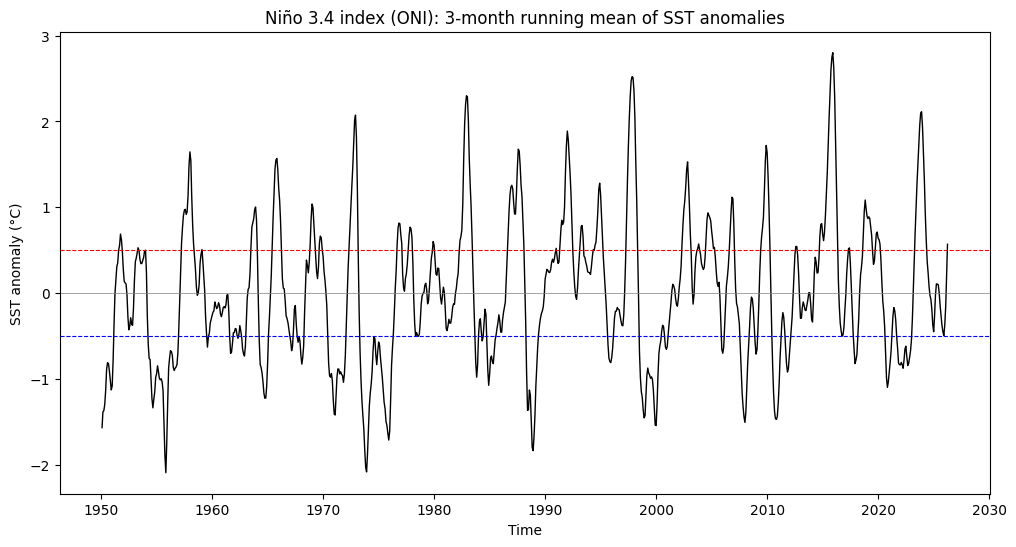

In [12]:
# Reopen dropping time_bnds and trim to 1950 onward (as we did in class)
nino_ds = xr.open_dataset(url, drop_variables=['time_bnds'], chunks={'time': 120})
nino_ds = nino_ds.sel(time=slice('1950', None)).load()

# Niño 3.4 region: 5S–5N, 170W–120W   (170W = 190E, 120W = 240E).
# ERSST latitude runs north -> south, so order the lat slice to match.
lat_slice = slice(5, -5) if nino_ds.lat[0] > nino_ds.lat[-1] else slice(-5, 5)
region = nino_ds.sst.sel(lat=lat_slice, lon=slice(190, 240))

# Area-weighted SST averaged over the region -> a single timeseries
w = np.cos(np.deg2rad(region.lat))
region_mean = region.weighted(w).mean(dim=['lat', 'lon'])

# Remove the seasonal cycle (climatology) to get anomalies
clim = region_mean.groupby('time.month').mean('time')
anom = region_mean.groupby('time.month') - clim

# Oceanic Niño Index (ONI) = 3-month running mean of the anomalies
oni = anom.rolling(time=3, center=True).mean()

oni.plot(color='k', lw=1)
plt.axhline(0, color='grey', lw=0.5)
plt.axhline(0.5, color='red',  ls='--', lw=0.8)
plt.axhline(-0.5, color='blue', ls='--', lw=0.8)
plt.title('Niño 3.4 index (ONI): 3-month running mean of SST anomalies')
plt.ylabel('SST anomaly (°C)');

## Submission instructions

When you're done, save your completed notebook as `assignment6.ipynb` inside the current week's folder in your private `clmt5405-assignments` GitHub repo, then push the commit:

```bash
git add <weekN>/assignment6.ipynb
git commit -m "Submit the Xarray SST lab"
git push
```

Then post a link to your completed notebook on the matching **Courseworks** assignment. Due Sunday night.